In [3]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Set Plot Style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [4]:
#Load Dataset
df = pd.read_csv("Data/titanic.csv")

In [17]:
#See Data
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [13]:
#Lihat Kolom Tersedia
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [14]:
#Jumlah Data
df.shape

(891, 12)

In [15]:
#Tipe Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [16]:
#Missing Value
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [19]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

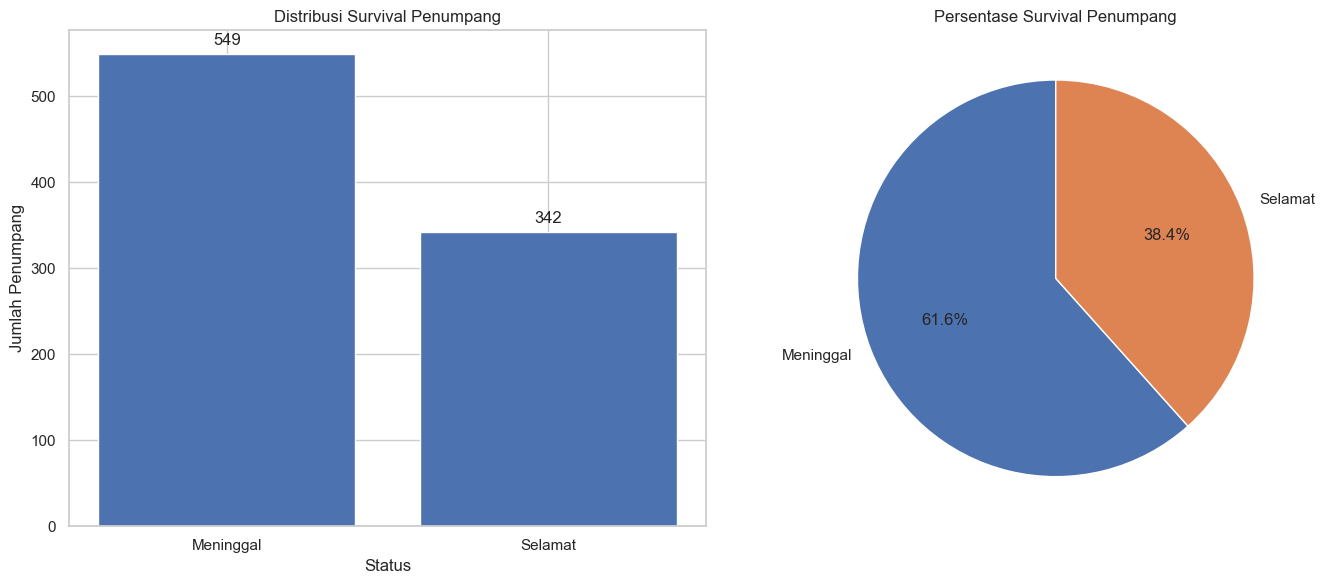

In [21]:
# Menghitung jumlah penumpang berdasarkan status survival
survival_count = df["Survived"].value_counts()

# Membuat label
labels = ["Meninggal", "Selamat"]
values = [survival_count.get(0, 0), survival_count.get(1, 0)]

# Membuat 2 visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar Chart
axes[0].bar(labels, values)
axes[0].set_title("Distribusi Survival Penumpang")
axes[0].set_xlabel("Status")
axes[0].set_ylabel("Jumlah Penumpang")

# Menambahkan angka di atas bar
for i, value in enumerate(values):
    axes[0].text(i, value + 10, str(value), ha="center")

# Pie Chart
axes[1].pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Persentase Survival Penumpang")

plt.tight_layout()
plt.show()

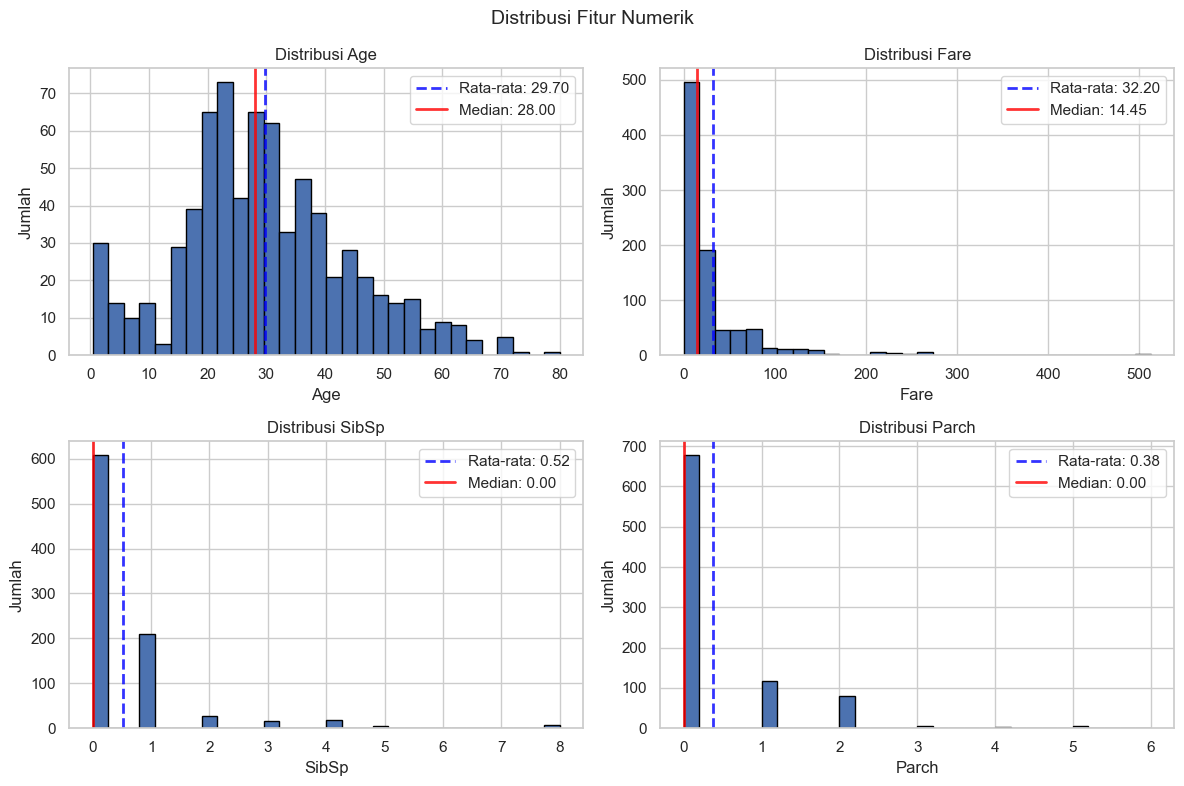

In [27]:
# Kolom numerik yang akan dianalisis
kolom_numerik = ["Age", "Fare", "SibSp", "Parch"]

# Membuat 4 grafik
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Mengubah axes menjadi satu dimensi
axes = axes.flatten()

# Membuat histogram untuk setiap kolom
for i, kolom in enumerate(kolom_numerik):
    data = df[kolom].dropna()

    # Histogram
    axes[i].hist(data, bins=30, edgecolor="black")

   # Garis rata-rata (Mean)
    axes[i].axvline(
    data.mean(),
    color="blue",
    linestyle="--",
    linewidth=2,
    alpha=0.8,
    label=f"Rata-rata: {data.mean():.2f}"
    )

    # Garis median
    axes[i].axvline(
    data.median(),
    color="red",
    linestyle="-",
    linewidth=2,
    alpha=0.8,
    label=f"Median: {data.median():.2f}"
    )

    # Judul dan label
    axes[i].set_title(f"Distribusi {kolom}")
    axes[i].set_xlabel(kolom)
    axes[i].set_ylabel("Jumlah")
    axes[i].legend()

# Judul utama
plt.suptitle("Distribusi Fitur Numerik", fontsize=14)

plt.tight_layout()
plt.show()